In [1]:
import boto3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

s3 = boto3.client("s3")
bucket_name = "dsan6000-nm1237"
prefix = "wikipedia-hourly/"

response = s3.list_objects_v2(Bucket=bucket_name, Prefix=prefix)
keys = [obj["Key"] for obj in response["Contents"] if obj["Key"].endswith(".parquet")]

dfs = []
for key in sorted(keys):
    uri = f"s3://{bucket_name}/{key}"
    df = pd.read_parquet(uri)
    dfs.append(df)

all_events = pd.concat(dfs, ignore_index=True)
print(all_events.shape)
all_events.head()

(119708, 29)


,datetime,$schema,meta,id,type,namespace,title,title_url,comment,timestamp,...,wiki,parsedcomment,log_id,log_type,log_action,log_params,log_action_comment,patrolled,file_ts,file_ts_str
0,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Jake_O%...,2.063884e+09,edit,0,Jake O'Donnell,https://en.wikipedia.org/wiki/Jake_O%27Donnell,Fix dash,1788235202,...,enwiki,Fix dash,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
1,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Beverid...,2.063884e+09,edit,0,Beveridge Award,https://en.wikipedia.org/wiki/Beveridge_Award,Add source,1788235202,...,enwiki,Add source,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
2,2026-09-01 04:00:01,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1920_Un...,2.063884e+09,edit,0,1920 United States presidential election in Wa...,https://en.wikipedia.org/wiki/1920_United_Stat...,/* Counties that flipped from Democratic to Re...,1788235201,...,enwiki,"<span class=""autocomment""><a href=""/wiki/1920_...",NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
3,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1987_Ae...,2.063884e+09,edit,0,1987 Aegean crisis,https://en.wikipedia.org/wiki/1987_Aegean_crisis,added a bit of context,1788235202,...,enwiki,added a bit of context,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
4,2026-09-01 04:00:03,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Marvin_...,2.063884e+09,edit,0,Marvin Schwäbe,https://en.wikipedia.org/wiki/Marvin_Schw%C3%A4be,NaN,1788235203,...,enwiki,NaN,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000


In [2]:
all_events["hour"] = pd.to_datetime(all_events["datetime"]).dt.floor("h")

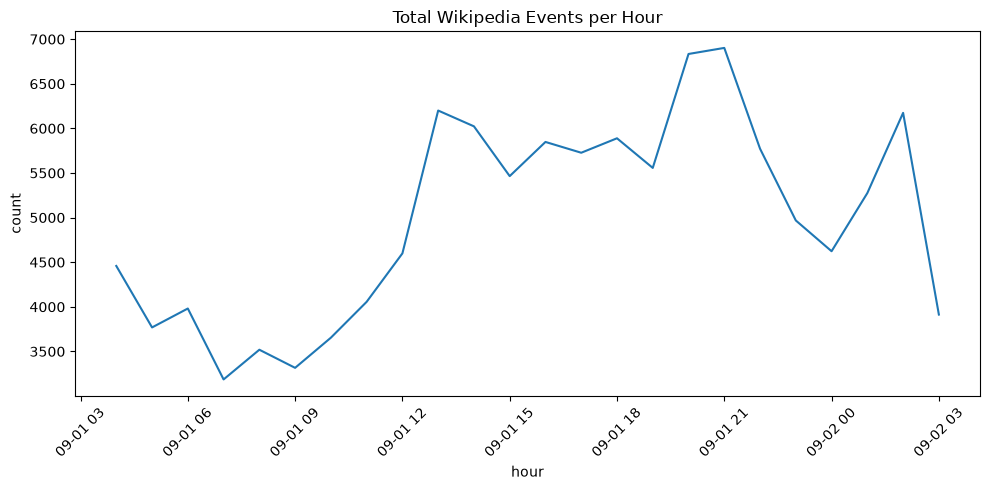

In [3]:
os.makedirs("images", exist_ok=True)

hourly_counts = all_events.groupby("hour").size().reset_index(name="count")

plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_counts, x="hour", y="count")
plt.title("Total Wikipedia Events per Hour")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/hourly-events.svg")
plt.savefig("images/hourly-events.png")
plt.show()

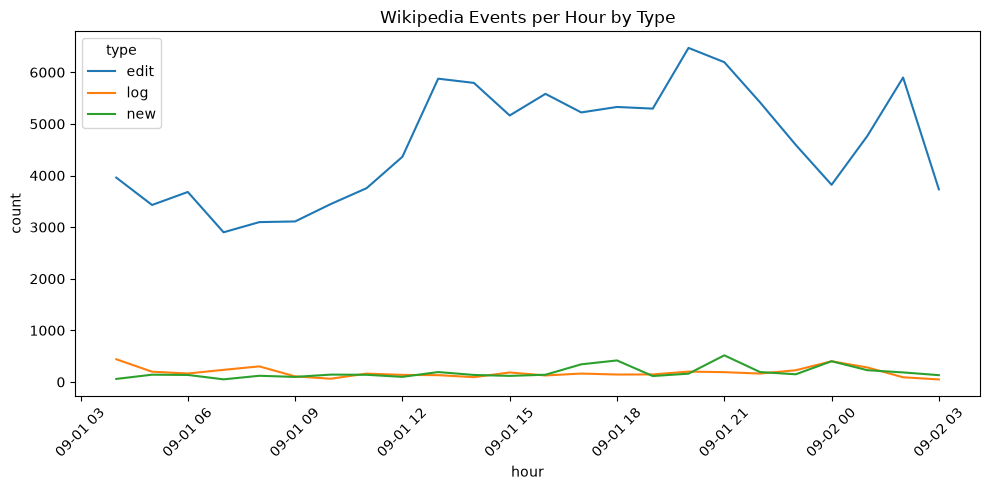

In [4]:
hourly_by_type = all_events.groupby(["hour", "type"]).size().reset_index(name="count")

plt.figure(figsize=(10, 5))
sns.lineplot(data=hourly_by_type, x="hour", y="count", hue="type")
plt.title("Wikipedia Events per Hour by Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/events-by-type.svg")
plt.savefig("images/events-by-type.png")
plt.show()